# CortexLab ZebraNoise — Quick Tour

Two-photon calcium imaging from the CortexLab, preprocessed and cached via [pixease](https://github.com/cortex-lab/pixease).

**37 sessions** across 3 mice (`BZ012`, `BZ014`, `MS019`) and 4 stimulus types:
`natural_images`, `resting_state`, `video`, `full_field_drifting_grating`.

Data directory: `D:/literatureData/CortexLab_ZebraNoise/`

In [1]:
%reload_ext autoreload
%autoreload 2

# Need the external data modules on path
import os, sys
external_path = os.getcwd()
sys.path.append(external_path)

import matplotlib.pyplot as plt
import numpy as np
from pixease_data import PixeaseRegistry

%matplotlib inline

## Registry — discover what's available

In [2]:
reg = PixeaseRegistry()
print(reg)
reg.available()

PixeaseRegistry(35 sessions, 3 mice, 4 stimulus types)
mouse     date          expnum    stimtype                        
--------  ------------  --------  --------------------------------
BZ012     2024-11-19    9         full_field_drifting_grating     
BZ012     2024-11-20    7         full_field_drifting_grating     
BZ012     2024-11-21    7         full_field_drifting_grating     
BZ014     2025-04-02    10        full_field_drifting_grating     
MS019     2025-02-11    11        full_field_drifting_grating     
MS019     2025-02-12    8         full_field_drifting_grating     
BZ012     2024-11-19    11        natural_images                  
BZ012     2024-11-19    7         natural_images                  
BZ012     2024-11-20    6         natural_images                  
BZ012     2024-11-20    9         natural_images                  
BZ012     2024-11-21    6         natural_images                  
BZ012     2024-11-21    9         natural_images                  
BZ014  

In [11]:
# Filter by stimulus type or mouse
reg.list(stimtype="full_field_drifting_grating")

[RecordingInfo('BZ012', '2024-11-19', expnum=9, stimtype='full_field_drifting_grating'),
 RecordingInfo('BZ012', '2024-11-20', expnum=7, stimtype='full_field_drifting_grating'),
 RecordingInfo('BZ012', '2024-11-21', expnum=7, stimtype='full_field_drifting_grating'),
 RecordingInfo('BZ014', '2025-04-02', expnum=10, stimtype='full_field_drifting_grating'),
 RecordingInfo('MS019', '2025-02-11', expnum=11, stimtype='full_field_drifting_grating'),
 RecordingInfo('MS019', '2025-02-12', expnum=8, stimtype='full_field_drifting_grating')]

## Load an experiment

Data loads lazily — nothing is read from disk until you access a property or call a method.

In [12]:
exp = reg.get("MS019", "2025-02-12", 8)
print(exp)  # not loaded yet

PixeaseExperiment('MS019', '2025-02-12', expnum=8, stimtype='full_field_drifting_grating', [not loaded])


In [ ]:
exp.summary()  # triggers load
print(exp)  # now loaded

Skipping ball because it is not in the cache file
=== Full field drifting gratings ===
Type: full_field_drifting_grating (2p, pipeline "full_field_drifting_gratings")
Mouse: MS019
Session: 2025-02-12 exp 8 (MS019_2025-02-12_8)
Duration: 8 repeats
Rig: b2 (1.3 zoom)
FOV: 7 x 512 x 512 (30 μm spacing)
Laser: 920nm (15% power)
Position: [1324.7, 7809.5, 4197.0]
Notes:


PixeaseExperiment('MS019', '2025-02-12', expnum=8, stimtype='full_field_drifting_grating', [loaded])


## Cell information

In [ ]:
print(f"Total ROIs:        {exp.n_cells}")
print(f"Curated cells:     {exp.iscell.sum()}")
print(f"Non-cell ROIs:     {(~exp.iscell).sum()}")

positions = exp.cellinfo.cell_positions()  # (n_cells, 3) in [z, y, x] pixels
print(f"Cell positions shape: {positions.shape}")

Total ROIs:        4390
Curated cells:     3660
Non-cell ROIs:     730
Cell positions shape: (4390, 3)


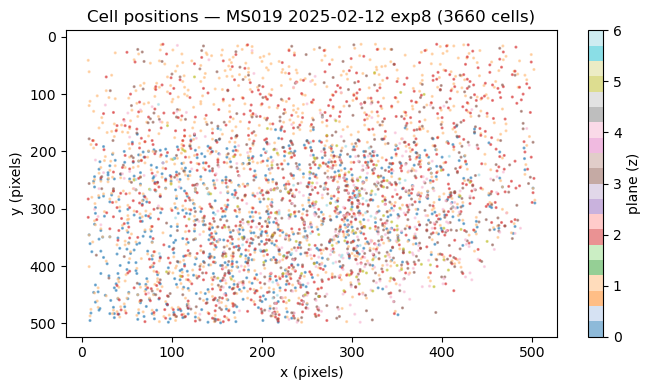

In [15]:
# Scatter cell positions coloured by plane
pos = positions[exp.iscell]
fig, ax = plt.subplots(figsize=(7, 4))
sc = ax.scatter(pos[:, 2], pos[:, 1], c=pos[:, 0], s=1.5, cmap="tab20", alpha=0.5)
plt.colorbar(sc, ax=ax, label="plane (z)")
ax.set_xlabel("x (pixels)")
ax.set_ylabel("y (pixels)")
ax.set_title(f"Cell positions — {exp.mouse} {exp.date} exp{exp.expnum} ({pos.shape[0]} cells)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Stimulus timings

In [16]:
trials = exp.stimulus_timings()
print(trials.shape)
trials.head(10)

(336, 7)


,duration,temporal_frequency,spatial_frequency,orientation,contrast,time_start,time_stop
0,2,8,0.04,90,1,12.165,14.184
1,2,1,0.04,45,1,15.163,17.201
2,2,1,0.04,225,1,18.179,20.218
3,2,8,0.04,180,1,21.197,23.234
4,2,4,0.04,90,1,24.212,26.251
5,2,1,0.04,1,0,27.229,29.267
6,2,4,0.04,315,1,30.245,32.284
7,2,4,0.04,45,1,33.263,35.301
8,2,8,0.04,270,1,36.279,38.317
9,2,4,0.04,135,1,39.297,41.334


In [31]:
trial_intervals = list(zip(*(trials["time_start"], trials["time_stop"])))
trial_resp = exp.interval_mean(trial_intervals, "dspikes", cells=exp.iscell)
print(f"trial_resp shape: {trial_resp.shape}  # (n_trials, n_cells)")

trial_resp shape: (336, 3660)  # (n_trials, n_cells)


In [32]:
import pandas as pd

cols = ["temporal_frequency", "orientation"]
mask = trials["contrast"] != 0
df_f = trials[mask]
data_f = trial_resp[mask]

codes = [pd.factorize(df_f[c], sort=True)[0] for c in cols]
shape = [df_f[c].nunique() for c in cols] + [exp.iscell.sum()]

result = np.zeros(shape)
counts = np.zeros(shape[:-1], dtype=int)

np.add.at(result, tuple(codes), data_f)
np.add.at(counts, tuple(codes), 1)

result /= counts[..., np.newaxis]

In [ ]:
result.shape
result_flat = np.reshape(result, (-1, result.shape[-1]))

True


In [35]:
# Get full data
resp_full = exp.timeseries((-np.inf, np.inf), "dspikes", smooth=None, cells=exp.iscell)

ValueError: Maximum allowed size exceeded

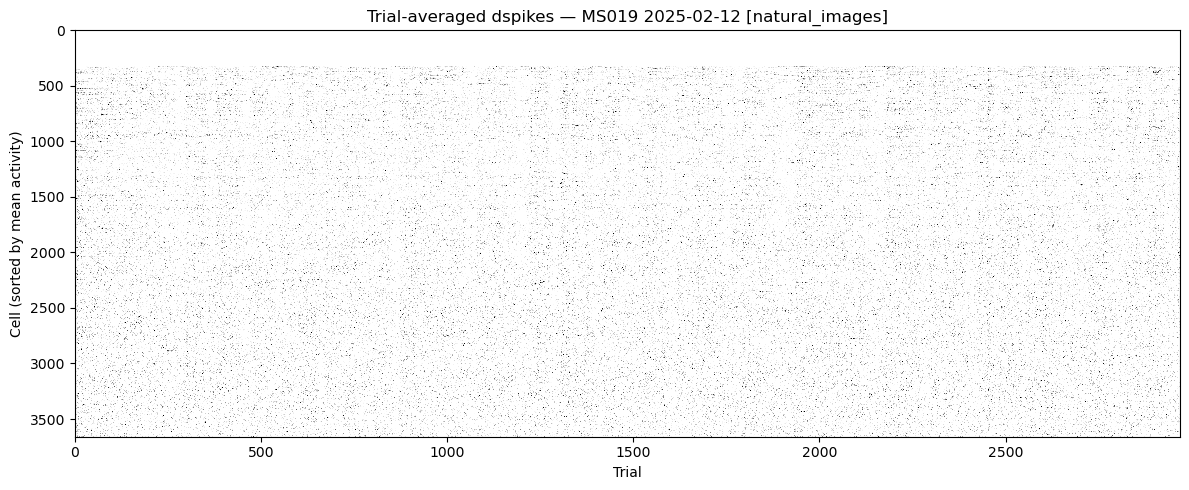

In [ ]:
# Sort cells by mean response across trials; show population heatmap
cell_order = np.argsort(trial_resp.mean(axis=0))[::-1]
display = trial_resp[:, cell_order].T

# Row-normalise for display
row_min = display.min(axis=1, keepdims=True)
row_max = display.max(axis=1, keepdims=True)
denom = np.where(row_max - row_min == 0, 1.0, row_max - row_min)
display_norm = (display - row_min) / denom

fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(display_norm, aspect="auto", cmap="gray_r", vmin=0, vmax=1, origin="upper", interpolation="none")
ax.set_xlabel("Trial")
ax.set_ylabel("Cell (sorted by mean activity)")
ax.set_title(f"Trial-averaged dspikes — {exp.mouse} {exp.date} [{exp.stimtype}]")
plt.tight_layout()
plt.show()

## Neural timeseries

Extract a continuously sampled trace for a specific time window.

In [ ]:
t_start, t_stop = exp.start_end_time()
print(f"Recording spans {t_start:.1f} – {t_stop:.1f} s  ({(t_stop - t_start)/60:.1f} min)")

# Sample a 60-second window
window = (t_start, t_start + 60.0)
neural = exp.timeseries(window, "dspikes", dt=0.05, cells=exp.iscell)  # (n_timepoints, n_cells)
times = exp.timeseries(window, "times", dt=0.05)
print(f"neural shape: {neural.shape}")

In [ ]:
# Show a few individual cell traces
n_show = 6
top_cells = np.argsort(neural.mean(axis=0))[::-1][:n_show]

fig, axes = plt.subplots(n_show, 1, figsize=(12, 6), sharex=True)
for i, ci in enumerate(top_cells):
    axes[i].plot(times, neural[:, ci], lw=0.8, color="steelblue")
    axes[i].set_ylabel(f"cell {ci}", fontsize=8)
    axes[i].set_yticks([])
axes[-1].set_xlabel("Time (s)")
fig.suptitle(f"Deconvolved spikes — top {n_show} active cells — {exp.mouse} {exp.date}", y=1.01)
plt.tight_layout()
plt.show()

## Behavioural co-variates: locomotion and pupil

In [ ]:
running = exp.timeseries(window, "running", dt=0.05, smooth=0.3)
pupil = exp.timeseries(window, "pupil_size", dt=0.05, smooth="interpolate")

fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
axes[0].plot(times, running, lw=0.8, color="darkorange")
axes[0].set_ylabel("Running speed")
axes[1].plot(times, pupil, lw=0.8, color="mediumpurple")
axes[1].set_ylabel("Pupil size")
axes[-1].set_xlabel("Time (s)")
fig.suptitle(f"Behaviour — {exp.mouse} {exp.date} exp{exp.expnum}")
plt.tight_layout()
plt.show()

## Resting state session

`resting_state` sessions have no discrete trials — just continuous neural and behavioural recordings.

In [ ]:
rest = reg.get("BZ012", "2024-11-19", 10)  # resting_state session same day
rest.summary()
print(f"\ncellinfo: {rest.n_cells} ROIs, {rest.iscell.sum()} curated")

In [ ]:
rt_start, rt_stop = rest.start_end_time()
rest_window = (rt_start, min(rt_start + 120.0, rt_stop))

rest_neural = rest.timeseries(rest_window, "dspikes", dt=0.05, cells=rest.iscell)
rest_times = rest.timeseries(rest_window, "times", dt=0.05)
rest_running = rest.timeseries(rest_window, "running", dt=0.05, smooth=0.3)

# Row-normalise for a compact population view
r_min = rest_neural.T.min(axis=1, keepdims=True)
r_max = rest_neural.T.max(axis=1, keepdims=True)
r_norm = (rest_neural.T - r_min) / np.where(r_max - r_min == 0, 1.0, r_max - r_min)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), gridspec_kw={"height_ratios": [5, 1]}, sharex=True)
axes[0].imshow(
    r_norm,
    aspect="auto",
    cmap="gray_r",
    vmin=0,
    vmax=1,
    origin="upper",
    interpolation="none",
    extent=[rest_times[0], rest_times[-1], r_norm.shape[0], 0],
)
axes[0].set_ylabel("Cell")
axes[0].set_title(f"Resting state — {rest.mouse} {rest.date} exp{rest.expnum}")
axes[1].plot(rest_times, rest_running, lw=0.8, color="darkorange")
axes[1].set_ylabel("Running")
axes[1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

## Full-field drifting grating session

In [ ]:
grat = reg.get("BZ012", "2024-11-19", 9)  # full_field_drifting_grating
grat.summary()
grat_trials = grat.stimulus_timings()
print(f"\n{len(grat_trials)} grating trials")
grat_trials.head()

In [ ]:
# Mean response per grating trial
grat_intervals = list(zip(grat_trials["time_start"], grat_trials["time_stop"]))
grat_resp = grat.interval_mean(grat_intervals, "dspikes", cells=grat.iscell)
print(f"grat_resp shape: {grat_resp.shape}  # (n_trials, n_cells)")

# Quick orientation-tuning check: mean response by orientation
if "orientation" in grat_trials.columns:
    oris = grat_trials["orientation"].values
    unique_oris = np.unique(oris[~np.isnan(oris)])
    mean_by_ori = np.array([grat_resp[oris == o].mean(axis=0) for o in unique_oris])  # (n_oris, n_cells)

    # Sort cells by preferred orientation
    pref = np.argmax(mean_by_ori, axis=0)
    cell_sort = np.argsort(pref)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.imshow(mean_by_ori[:, cell_sort].T, aspect="auto", cmap="inferno", origin="upper")
    ax.set_xticks(range(len(unique_oris)))
    ax.set_xticklabels([f"{o:.0f}°" for o in unique_oris], rotation=45, ha="right")
    ax.set_xlabel("Orientation")
    ax.set_ylabel("Cell (sorted by pref. orientation)")
    ax.set_title(f"Orientation tuning — {grat.mouse} {grat.date} exp{grat.expnum}")
    plt.tight_layout()
    plt.show()
else:
    print("Column 'orientation' not found — check grat_trials.columns for the right name.")